# California Housing Price Analysis_Insights & Linear Regression Modeling

##  Objective
This project explores the key factors influencing housing prices in California through exploratory data analysis (EDA),data visualization and feature engineering, culminating in a Linear Regression model to predict property values.

##  Key Questions
- To what extent does median income affect house prices?
- How does geographic location influence housing value?
- Do housing density features impact pricing?
- How accurate is our Linear Regression model in predicting house prices?


### Import the nessessory libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data as CSV file

In [2]:
data=pd.read_csv('/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv')
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Iinitial exploration

In [3]:
data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [4]:
data.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [5]:
data.shape

(20640, 10)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


##  Data Cleaning

### Handling Missing Data

In [8]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
data['total_bedrooms']=data['total_bedrooms'].fillna(data['total_bedrooms'].median())
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

**Interpretation**: The columns become didnot contain missing values.

**Interpretation**: Since the variable may contain outliers,the median provides a more robust estimate than the mean. we avoided Deleting rows to keep dataset size and prevent loss useful information.

### Outlier Treatment

#### In (housing_median_age) column

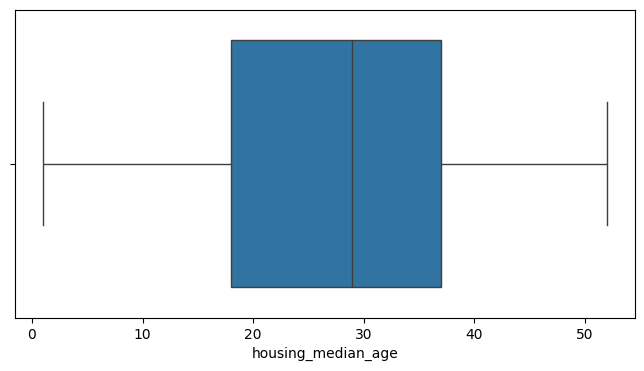

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['housing_median_age'])
plt.show()

**Interpretation**: NO outliers in this column

#### In (total_rooms) column

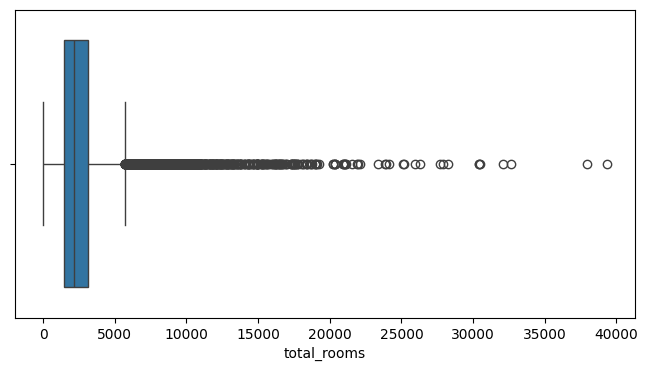

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['total_rooms'])
plt.show()

In [12]:
Q1 = data['total_rooms'].quantile(0.25)
Q3 = data['total_rooms'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['total_rooms'] < lower) | (data['total_rooms'] > upper)]
print(len(outliers))

1287


In [13]:
data['total_rooms']=data['total_rooms'].clip(lower,upper)

#### In (total_bedrooms) column

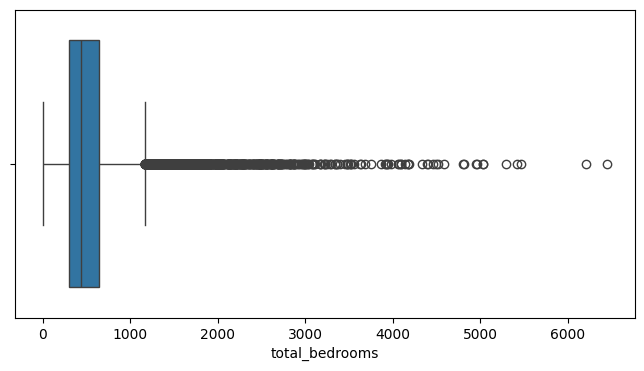

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['total_bedrooms'])
plt.show()

In [15]:
Q1=data['total_bedrooms'].quantile(0.25)
Q3=data['total_bedrooms'].quantile(0.75)
IQR=Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['total_bedrooms'] < lower) | (data['total_bedrooms'] > upper)]
print(len(outliers))

1306


In [16]:
data['total_bedrooms']=data['total_bedrooms'].clip(lower,upper)

#### In (population) column

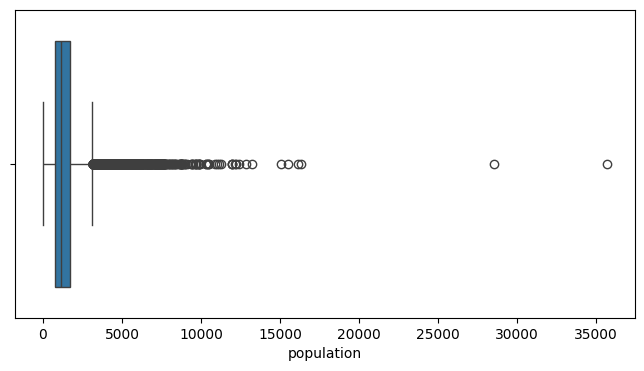

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['population'])
plt.show()

In [18]:
Q1=data['population'].quantile(0.25)
Q3=data['population'].quantile(0.75)
IQR=Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['population'] < lower) | (data['population'] > upper)]
print(len(outliers))

1196


In [19]:
data['population']=data['population'].clip(lower,upper)

#### In (households) column

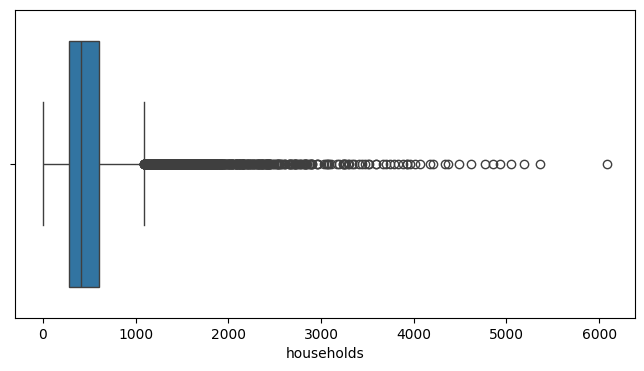

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['households'])
plt.show()

In [21]:
Q1=data['households'].quantile(0.25)
Q3=data['households'].quantile(0.75)
IQR=Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['households'] < lower) | (data['households'] > upper)]
print(len(outliers))

1220


In [22]:
data['households']=data['households'].clip(lower,upper)

#### In (median_income) column

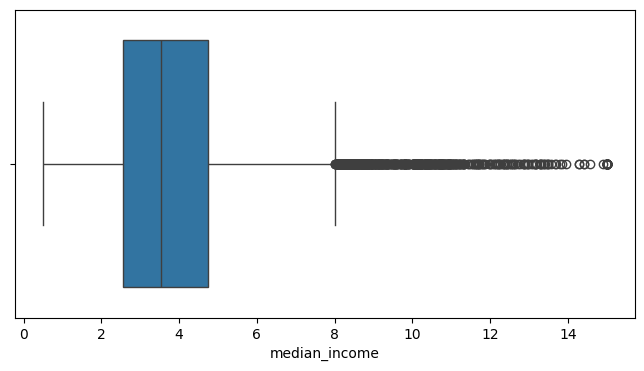

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['median_income'])
plt.show()

In [24]:
Q1 = data['median_income'].quantile(0.25)
Q3 = data['median_income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['median_income'] < lower) | (data['median_income'] > upper)]
print(len(outliers))

681


In [25]:
data['median_income'] = data['median_income'].clip(lower, upper)

#### In (median_house_value) column

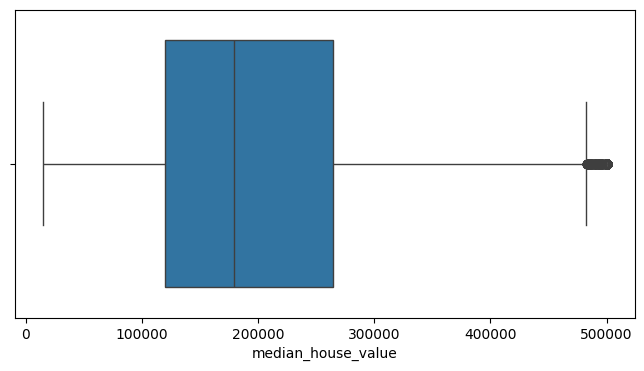

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['median_house_value'])
plt.show()

In [27]:
Q1=data['median_house_value'].quantile(0.25)
Q3=data['median_house_value'].quantile(0.75)
IQR=Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR  

outliers = data[(data['median_house_value'] < lower) | (data['median_house_value'] > upper)]
print(len(outliers))

1071


In [28]:
data['median_house_value']=data['median_house_value'].clip(lower,upper)

#### Columns after outlier treatment

**Interpretation**: We use winsorization  because the outliers may represent natural variation rather than data entry errors, Winsorization was applied to reduce their impact without removing them.

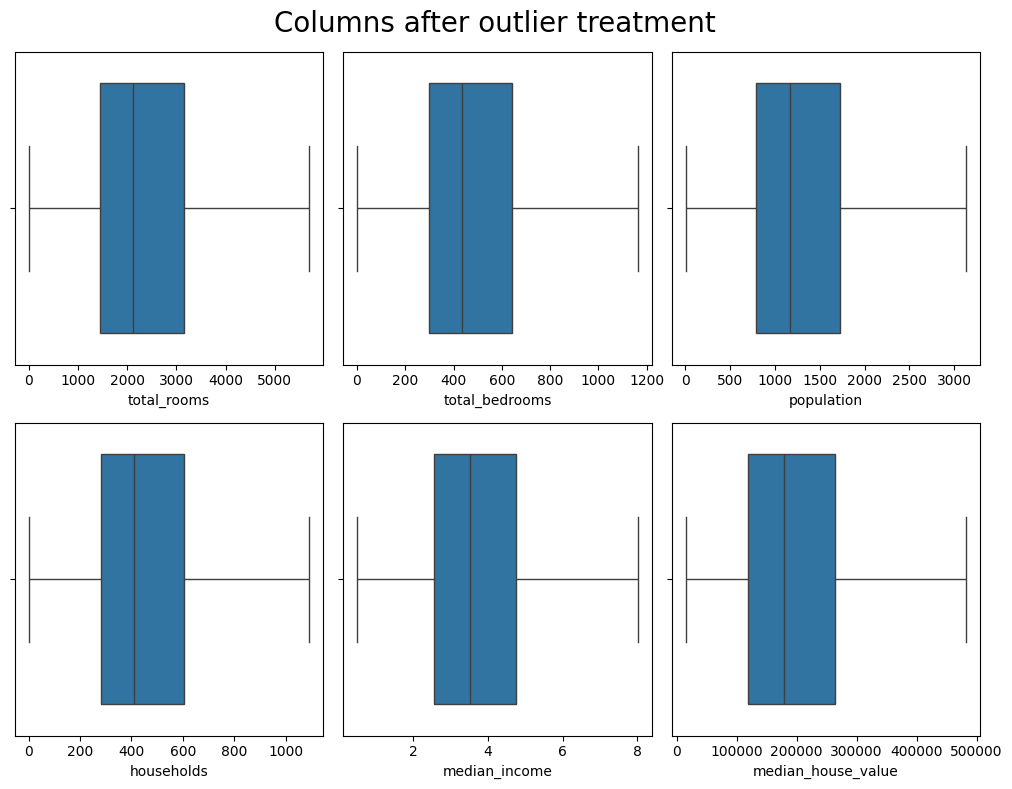

In [29]:
fig,ax=plt.subplots(2,3,figsize=(10,8))
fig.suptitle('Columns after outlier treatment', fontsize=20)
#subplot1
sns.boxplot(x=data['total_rooms'],ax=ax[0,0])

#subplot2
sns.boxplot(x=data['total_bedrooms'],ax=ax[0,1])

#subplot3
sns.boxplot(x=data['population'],ax=ax[0,2])

#subplot4
sns.boxplot(x=data['households'],ax=ax[1,0])

#subplot5
sns.boxplot(x=data['median_income'],ax=ax[1,1])

#subplot6
sns.boxplot(x=data['median_house_value'],ax=ax[1,2])

plt.tight_layout() 
plt.show() 

**Interpretation**: The columns become did not contain extreme values.

### Feature Transformation

#### Data type convarsion

In [30]:
data['ocean_proximity']=data['ocean_proximity'].astype('category')

- No encoding and scaling now:
1. The **ocean_proximity** column was maintained in its original text format to ensuring easy-to-read plots and understand results directly without needing to refer to decoding tables , The encoding process will be postponed to the preprocessing stage to fit with machine learning algorithms.
2. **Scaling** depends on the model type.

## Documentation

- I have shown the number of missing values ​​before and after the processing operation in the section(Handling Missing Data).
- I created Boxplot to detect the outliers befor and after the processing operation  in the sectioon(Outlier Treatment).

In [31]:
summary = pd.DataFrame({
    'Step': ['Handled missing values','Outlier treatment','Encoding categorical variable','Feature scaling'],
    'Method Used': ['Median imputation','IQR clipping','No encoding now','No Scalening'],
    'Reason': ['Reduce data loss','Reduce extreme influence','to ensuring easy-to-read plots and understand results directly','depends on the model type']})
summary

,Step,Method Used,Reason
0,Handled missing values,Median imputation,Reduce data loss
1,Outlier treatment,IQR clipping,Reduce extreme influence
2,Encoding categorical variable,No encoding now,to ensuring easy-to-read plots and understand ...
3,Feature scaling,No Scalening,depends on the model type


## Feature Engineering

### Create housing age groupe feature

In [32]:
bins=[0,10,20,30,40,50,60]
labels=['0-10','11-20','21-30','31-40','41-50','51-60']
data['housing age groupe']=pd.cut(data['housing_median_age'],bins,labels=labels)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,housing age groupe
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,452600.0,NEAR BAY,41-50
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,358500.0,NEAR BAY,21-30
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,352100.0,NEAR BAY,51-60
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,341300.0,NEAR BAY,51-60
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,342200.0,NEAR BAY,51-60


- The housing age group column was created to transform numerical data into categorical groups, making it easier to compare the impact of different age groups on house prices.

### Create people per household feature

In [33]:
data['people per household']=data['population']/data['households']
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,housing age groupe,people per household
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,452600.0,NEAR BAY,41-50,2.555556
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,358500.0,NEAR BAY,21-30,2.197712
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,352100.0,NEAR BAY,51-60,2.802260
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,341300.0,NEAR BAY,51-60,2.547945
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,342200.0,NEAR BAY,51-60,2.181467


- This feature indicates whether an area is populated by large families or single individuals,as house prices are often linked to the number of people per household.

- We create new feature but it contain outliers so we need to clip it.

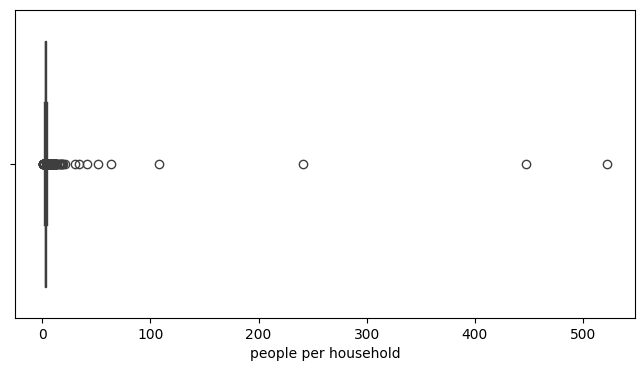

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['people per household'])
plt.show()

In [35]:
Q1=data['people per household'].quantile(0.25)
Q3=data['people per household'].quantile(0.75)
IQR=Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR  

data['people per household']=data['people per household'].clip(lower,upper)

In [36]:
data['people per household'].describe()

count    20640.000000
mean         2.892974
std          0.659779
min          1.257304
25%          2.451816
50%          2.849303
75%          3.248158
max          4.442671
Name: people per household, dtype: float64

### Create rooms per household feature

In [37]:
data['rooms per household']=data['total_rooms']/data['households']
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,housing age groupe,people per household,rooms per household
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,452600.0,NEAR BAY,41-50,2.555556,6.984127
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,358500.0,NEAR BAY,21-30,2.197712,5.215904
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,352100.0,NEAR BAY,51-60,2.802260,8.288136
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,341300.0,NEAR BAY,51-60,2.547945,5.817352
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,342200.0,NEAR BAY,51-60,2.181467,6.281853


- This feature represents the average living space available per family,this ratio provides a clearer picture of housing quality which shows a positive correlation with house values.

-  We create new feature but it contain outliers so we need to clip it.

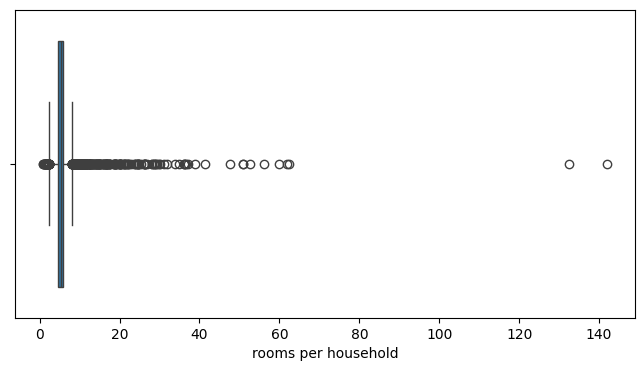

In [38]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['rooms per household'])
plt.show()

In [39]:
Q1=data['rooms per household'].quantile(0.25)
Q3=data['rooms per household'].quantile(0.75)
IQR=Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR  

data['rooms per household']=data['rooms per household'].clip(lower,upper)

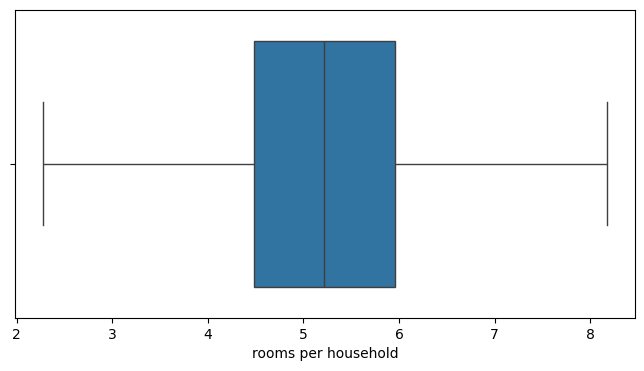

In [40]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['rooms per household'])
plt.show()

## Data Visualization

### Relationships

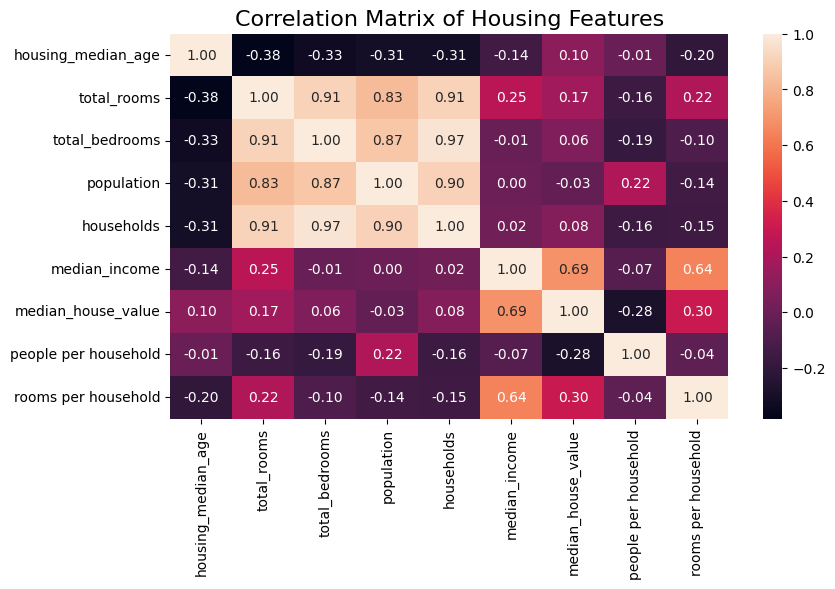

In [41]:
plt.figure(figsize=(9,5))
numeric_df = data.select_dtypes(include=['float'])
numeric_df=numeric_df.drop(['longitude', 'latitude'], axis=1)
corr=numeric_df.corr()
sns.heatmap(corr,annot=True,fmt='0.2f')
plt.title('Correlation Matrix of Housing Features', fontsize=16)
plt.show()

- This Correlation Matrix shows the strength of the relationship between different numerical variables.
- There is strong positive relationship between **median_income** and **median_house_value**.
- There is very strong posistive relationship between **total_rooms** , **total_bedrooms** and **population** 
these variables can be combined to avoid duplication.

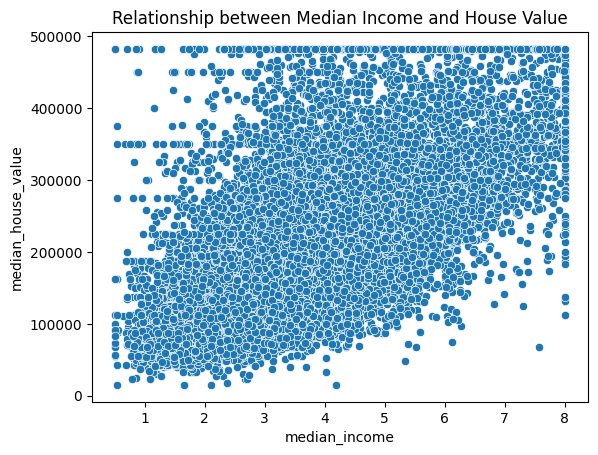

In [42]:
sns.scatterplot(x='median_income',y='median_house_value',data=data)
plt.title('Relationship between Median Income and House Value')
plt.show()

- The scatter plot clearly illustrates a strong upward trend, where higher median income levels correspond with increased median house values However there is a horizontal line at the $500,000 indicating that the data has been capped at this maximum value , and a vertical line at the 8 indecating the data has been capped at the maximum value of median income.

### Distributions 

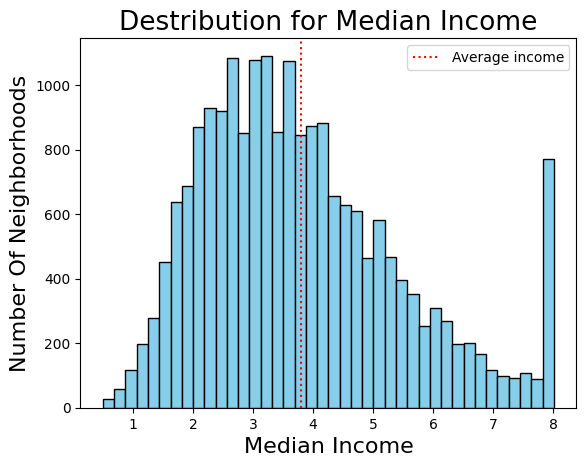

In [43]:
plt.hist(data['median_income'],bins=40,color='skyblue',edgecolor='black')
plt.xlabel('Median Income',fontsize=16)
plt.ylabel('Number Of Neighborhoods',fontsize=16)
plt.title('Destribution for Median Income',fontsize=19)
plt.axvline(data['median_income'].mean(),color='red',linestyle=':',label='Average income')
plt.legend()
plt.show()

- The distribution of median income closely like a Normal Distribution, as the mean and median are approximately equal. This symmetry indicates a healthy data spread for most districts, exception of the upper cap at 8.

### Comparisons/Trends

/tmp/ipykernel_16/779230455.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_location = data.groupby('ocean_proximity')['median_house_value'].median().sort_values()


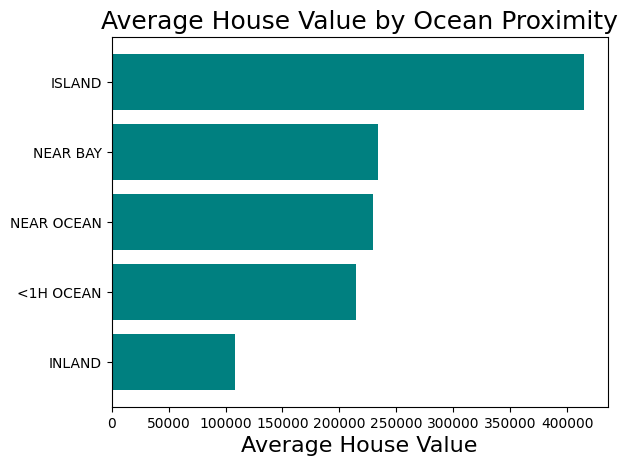

In [44]:
avg_price_by_location = data.groupby('ocean_proximity')['median_house_value'].median().sort_values()
plt.barh(avg_price_by_location.index,avg_price_by_location.values,color='teal')
plt.title('Average House Value by Ocean Proximity',fontsize=18)
plt.xlabel('Average House Value',fontsize=16)
plt.show()

- The horizontal bar chart reveals a relationship between geographic proximity to the ocean and median house values:
Properties located on islands the highest with an average house value nearing $380,000, Inland properties are the cheapest, with average house value below $150,000.

## Statistical Modeling & Insights

### Statistical Modeling

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

- The ocean_proximity text column must be converted to numbers (One-Hot Encoding) for the linear regression model understand it.

In [46]:
data = pd.get_dummies(data, columns=['ocean_proximity'],dtype=float)
data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,housing age groupe,people per household,rooms per household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.013025,452600.0,41-50,2.555556,6.984127,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.013025,358500.0,21-30,2.197712,5.215904,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,352100.0,51-60,2.802260,8.173419,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,341300.0,51-60,2.547945,5.817352,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,342200.0,51-60,2.181467,6.281853,0.0,0.0,0.0,1.0,0.0


- Identifying variables (x,y) and split the data 80% train , 20% test

In [47]:
features = ['median_income', 'housing_median_age','rooms per household','people per household','longitude', 'latitude'] \
+ [col for col in data.columns if 'ocean_proximity' in col]
x = data[features]
y = data['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

- Create the model and train it.

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

- Performance evaluation 

In [49]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"R² Score: {r2:.2f}")
print(f"RMSE: ${rmse:,.2f}")

R² Score: 0.65
RMSE: $66,982.58


Interpretation:
1. The R^2 score 0.65 indicates that approximately 65% of the variation in house prices is explained by our models features .
2. The RMSE value shows that on average the model’s predictions deviate from the actual house prices by about $66,982. This is our average "prediction error".

### Final Insights

1. We conclude that **median income** is the **strongest** variable in predicting housing value.
2. We concluded that houses in island are the highest price , and houses in coastal areas are two times more than those in the inland.
3. We discovered there is moderate positive correlation between **rooms per household** and **house value** ,
  and strong positive correlation between **rooms per household** and **median income**. 
4. **Unexpected pattern**: We expected that an increase in population might reduce house prices in a certain block, but we discovered that
  population size does not significantly affect house prices.
5. **Limitation**: The dataset does not contain critical data like inside house status and services provided in the block(schools,hospital,...)
6. **Future improvement**: Add data in dataset like schools proximity and provided services that can improve data analysis quality and  
  predicting accuracy.